## Лабораторная работа Nº3.


Разработка имитационной модели одноканальной вычислительной системы с
отказами.

## Задание №1

In [52]:
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [53]:
_lambda = 0.5 # интенсивность входного потока программ
_mu = 0.6 # интенсивность обработки программ

In [54]:
Tz_test = [0, 0.12, 1.291, 6.594, 6.821, 9.031, 14.971, 17.15]
Ts_test = [0, 0.634, 2.31, 6.78, 0.477, 5.104, 0.459, 1.442]
Tmod = 17

In [55]:
processed_programs = 4
rejections = 2
total_programs = 6
processing_probability = 0.667
cpu_time = 10.201
idle_time = 5.127
total_time = 17.15
cpu_utilization = 0.594
idle_probability = 0.299

print(f'Число обработанных программ: {processed_programs}')
print(f'Число отказов: {rejections}')
print(f'Общее число поступивших программ: {total_programs}')
print(f'Вероятность обработки: {processing_probability}')
print(f'Время работы процессора: {cpu_time} с')
print(f'Время простоя (между обслуживаниями): {idle_time} с')
print(f'Общее время моделирования: {total_time} с')
print(f'Загрузка процессора: {cpu_utilization}')
print(f'Вероятность простоя: {idle_probability}')


Число обработанных программ: 4
Число отказов: 2
Общее число поступивших программ: 6
Вероятность обработки: 0.667
Время работы процессора: 10.201 с
Время простоя (между обслуживаниями): 5.127 с
Общее время моделирования: 17.15 с
Загрузка процессора: 0.594
Вероятность простоя: 0.299


## Задание №2

Разработать компьютерную программу для имитационного моделирования
одноканальной ВС. На вход системы поступает случайный поток программ,
распределенных по экспоненциальному закону с интенсивностью - L [1/сек]. Обработка программ - случайный процесс с интенсивностью - mu [1/сек].

In [56]:
import numpy as np

def model(Tz, Ts, Tmod):
    """
    Tz — моменты поступления заявок
    Ts — времена обслуживания
    Tmod — время моделирования
    """

    # Инициализация: обрабатываем первую заявку до цикла
    Tsb = Tz[1]       # момент начала обслуживания
    dTs = Ts[1]       # длительность обслуживания первой заявки
    Tse = Tsb + dTs   # момент окончания обслуживания
    busy_time = dTs   # суммарное время работы процессора
    processed = 1     # число обработанных заявок
    refused = 0       # число отказов
    idle_time = 0     # суммарное время простоя
    j = 1             # индекс в Ts — растёт только при принятии заявки

    i = 2
    while i < len(Tz) and Tz[i] < Tmod:
        arrival = Tz[i]

        if Tse < arrival:               # процессор свободен
            idle_time += arrival - Tse  # накапливаем простой
            j += 1
            dTs = Ts[j]                 # берём Ts[j], а не Ts[i]
            Tsb = arrival
            Tse = Tsb + dTs
            busy_time += dTs
            processed += 1
        else:                           # процессор занят — отказ
            refused += 1

        i += 1


    total_arrived = processed + refused
    relative_throughput = processed / total_arrived if total_arrived > 0 else 0
    cpu_load = busy_time / Tmod if Tmod > 0 else 0
    cpu_idle_prob = idle_time / Tmod if Tmod > 0 else 0

    return (
        processed,
        refused,
        total_arrived,
        round(relative_throughput, 3),
        round(busy_time, 3),
        round(idle_time, 3),
        round(Tmod, 3),
        round(cpu_load, 3),
        round(cpu_idle_prob, 3)
    )

In [57]:
def generate_stream(lmbda, mu, Tmod):
    Tz = [0]
    Ts = [0]

    current_time = 0

    while current_time < Tmod:
        interarrival = np.random.exponential(1/lmbda)
        current_time += interarrival
        Tz.append(current_time)

        service_time = np.random.exponential(1/mu)
        Ts.append(service_time)

    return Tz, Ts

In [58]:
tz, ts = generate_stream(lmbda=_lambda, mu=_mu, Tmod=Tmod)
print(tz)
print(ts)

[0, 0.9385361799537182, 3.572027567044617, 3.9112773079693093, 4.03095484518667, 5.8691191524412, 5.9107177684394765, 9.483576855148826, 9.884934832648153, 10.610442291569107, 11.741516425129781, 13.634258172929378, 14.325289196934182, 15.543158572653732, 15.988630296911113, 17.783639739530635]
[0, 5.016869051529202, 1.5215709229599221, 0.282660486524342, 3.352051440799899, 2.052083436174317, 5.839262458597187, 0.397812708748245, 0.3376857047204284, 1.239879718101424, 0.5737049875899025, 0.25039088121223113, 0.7604620303680785, 2.56322668505152, 1.203381925055213, 0.07927308292734758]


## Задание №3

Для разработанной имитационной модели ВС провести ее тестирование путем сопоставления выходных значений, полученных с помощью компьютерной программы, разработанной в результате выполнения задания Nº2 и значений, полученных в результате выполнения задания Nº1.

In [59]:
Tz_test = [0, 0.12, 1.291, 6.594, 6.821, 9.031, 14.971, 17.15]
Ts_test = [0, 0.634, 2.31, 6.78, 0.477, 5.104, 0.459, 1.442]
Tmod = 17.15

result = model(Tz_test, Ts_test, Tmod)

result

(4, 2, 6, 0.667, 10.201, 5.127, 17.15, 0.595, 0.299)

In [60]:
print(f'Число обработанных программ: {result[0]}')
print(f'Число отказов: {result[1]}')
print(f'Общее число поступивших программ: {result[2]}')
print(f'Вероятность обработки: {result[3]}')
print(f'Время работы процессора: {result[4]} с')
print(f'Время простоя (между обслуживаниями): {result[5]} с')
print(f'Общее время моделирования: {result[6]} с')
print(f'Загрузка процессора: {result[7]}')
print(f'Вероятность простоя: {result[8]}')


Число обработанных программ: 4
Число отказов: 2
Общее число поступивших программ: 6
Вероятность обработки: 0.667
Время работы процессора: 10.201 с
Время простоя (между обслуживаниями): 5.127 с
Общее время моделирования: 17.15 с
Загрузка процессора: 0.595
Вероятность простоя: 0.299


In [61]:
print('=' * 140)
print('СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЗАДАНИЯ 1 И ЗАДАНИЯ 2')
print('=' * 140)
print()

print(f'{"Параметр":<40} {"Задание 1":<15} {"Задание 2":<15} {"Разница":<10}')
print('-' * 140)
print(f'{"Число обработанных программ":<40} {processed_programs:<15} {result[0]:<15} {result[0] - processed_programs:<10}')
print(f'{"Число отказов":<40} {rejections:<15} {result[1]:<15} {result[1] - rejections:<10}')
print(f'{"Общее число поступивших программ":<40} {total_programs:<15} {result[2]:<15} {result[2] - total_programs:<10}')
print(f'{"Вероятность обработки":<40} {processing_probability:<15} {result[3]:<15} {result[3] - processing_probability:<10}')
print(f'{"Время работы процессора (с)":<40} {cpu_time:<15} {result[4]:<15} {result[4] - cpu_time:<10}')
print(f'{"Время простоя (с)":<40} {idle_time:<15} {result[5]:<15} {result[5] - idle_time:<10}')
print(f'{"Общее время моделирования (с)":<40} {total_time:<15} {result[6]:<15} {result[6] - total_time:<10}')
print(f'{"Загрузка процессора":<40} {cpu_utilization:<15} {result[7]:<15} {result[7] - cpu_utilization:<10}')
print(f'{"Вероятность простоя":<40} {idle_probability:<15} {result[8]:<15} {result[8] - idle_probability:<10}')
print('=' * 140)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ЗАДАНИЯ 1 И ЗАДАНИЯ 2

Параметр                                 Задание 1       Задание 2       Разница   
--------------------------------------------------------------------------------------------------------------------------------------------
Число обработанных программ              4               4               0         
Число отказов                            2               2               0         
Общее число поступивших программ         6               6               0         
Вероятность обработки                    0.667           0.667           0.0       
Время работы процессора (с)              10.201          10.201          0.0       
Время простоя (с)                        5.127           5.127           0.0       
Общее время моделирования (с)            17.15           17.15           0.0       
Загрузка процессора                      0.594           0.595           0.0010000000000000009
Вероятность простоя                      0.299 

## Задание №4

Провести анализ работы заданной структуры ВС в виде выходных характеристик имитационной модели ВС - относительной пропускной способности ВС и загрузки процессора в зависимости от коэффициента загрузки - po=L/mu. Сопоставить эти значения с аналитическими, полученными для одноканальной ВС без накопителя на основе теории массового облуживания.

In [62]:
def run_experiment(lmbda, mu, Tmod=100):
    Tz, Ts = generate_stream(lmbda, mu, Tmod)
    res = model(Tz, Ts, Tmod)

    Q_sim = res[3]      # относительная пропускная способность
    load_sim = res[7]   # загрузка процессора

    return Q_sim, load_sim

In [63]:
import matplotlib.pyplot as plt

mu = 1
rho_values = np.linspace(0.01, 1, 100)

Q_sim_list = []
load_sim_list = []
Q_theory = []
load_theory = []

for rho in rho_values:
    lmbda = rho * mu

    Q_sim, load_sim = run_experiment(lmbda, mu, Tmod=100)

    Q_sim_list.append(Q_sim)
    load_sim_list.append(load_sim)

    Q_theory.append(1/(1+rho))
    load_theory.append(rho/(1+rho))

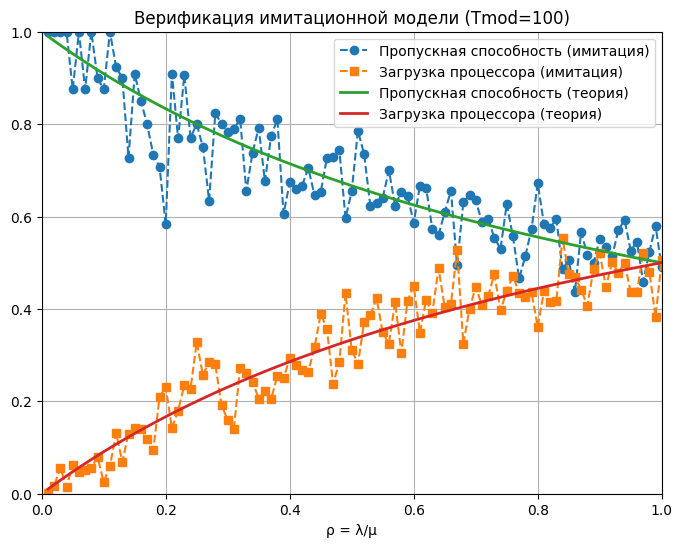

In [64]:
plt.figure(figsize=(8, 6))
plt.plot(rho_values, Q_sim_list,    label='Пропускная способность (имитация)',        marker='o', linestyle='--')
plt.plot(rho_values, load_sim_list, label='Загрузка процессора (имитация)', marker='s', linestyle='--')
plt.plot(rho_values, Q_theory,      label='Пропускная способность (теория)',          linewidth=2)
plt.plot(rho_values, load_theory,   label='Загрузка процессора (теория)',   linewidth=2)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Верификация имитационной модели (Tmod=100)')
plt.xlabel('ρ = λ/μ')
plt.legend()
plt.grid(True)
plt.show()
# Q - относительная пропускная способность

In [65]:
import matplotlib.pyplot as plt

mu = 1
rho_values = np.linspace(0.01, 1, 100)

Q_sim_list = []
load_sim_list = []
Q_theory = []
load_theory = []

for rho in rho_values:
    lmbda = rho * mu

    Q_sim, load_sim = run_experiment(lmbda, mu, Tmod=1000)

    Q_sim_list.append(Q_sim)
    load_sim_list.append(load_sim)

    Q_theory.append(1/(1+rho))
    load_theory.append(rho/(1+rho))

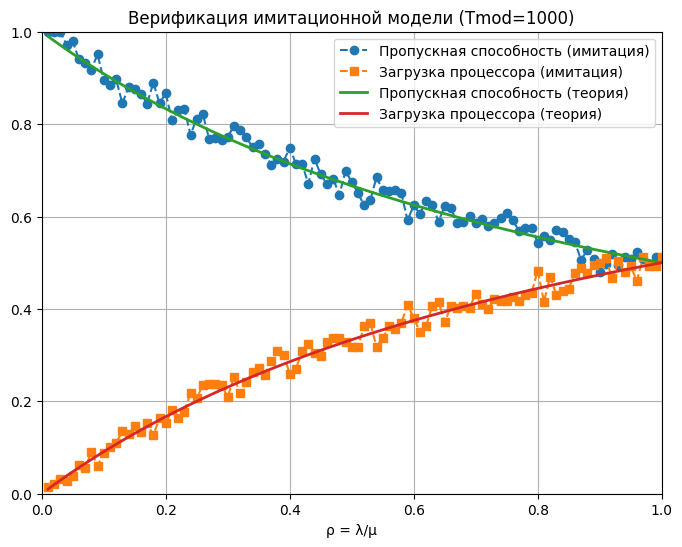

In [66]:
plt.figure(figsize=(8, 6))
plt.plot(rho_values, Q_sim_list,    label='Пропускная способность (имитация)',        marker='o', linestyle='--')
plt.plot(rho_values, load_sim_list, label='Загрузка процессора (имитация)', marker='s', linestyle='--')
plt.plot(rho_values, Q_theory,      label='Пропускная способность (теория)',          linewidth=2)
plt.plot(rho_values, load_theory,   label='Загрузка процессора (теория)',   linewidth=2)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Верификация имитационной модели (Tmod=1000)')
plt.xlabel('ρ = λ/μ')
plt.legend()
plt.grid(True)
plt.show()
# Q - относительная пропускная способность

In [67]:
import matplotlib.pyplot as plt

mu = 1
rho_values = np.linspace(0.01, 1, 100)

Q_sim_list = []
load_sim_list = []
Q_theory = []
load_theory = []

for rho in rho_values:
    lmbda = rho * mu

    Q_sim, load_sim = run_experiment(lmbda, mu, Tmod=10_000)

    Q_sim_list.append(Q_sim)
    load_sim_list.append(load_sim)

    Q_theory.append(1/(1+rho))
    load_theory.append(rho/(1+rho))

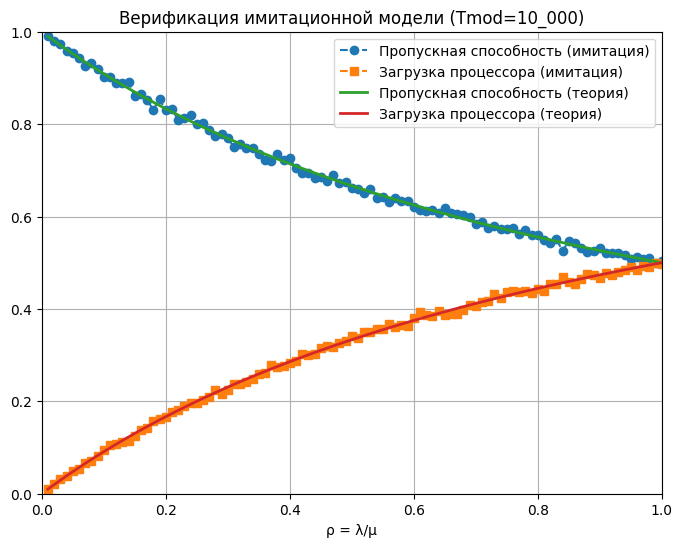

In [68]:
plt.figure(figsize=(8, 6))
plt.plot(rho_values, Q_sim_list,    label='Пропускная способность (имитация)',        marker='o', linestyle='--')
plt.plot(rho_values, load_sim_list, label='Загрузка процессора (имитация)', marker='s', linestyle='--')
plt.plot(rho_values, Q_theory,      label='Пропускная способность (теория)',          linewidth=2)
plt.plot(rho_values, load_theory,   label='Загрузка процессора (теория)',   linewidth=2)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Верификация имитационной модели (Tmod=10_000)')
plt.xlabel('ρ = λ/μ')
plt.legend()
plt.grid(True)
plt.show()
# Q - относительная пропускная способность